In [ ]:
#%pip install opencv-python opencv-contrib-python numpy matplotlib scikit-learn


### Importamos librerias necesarias

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

#configuracion inicial

In [ ]:
warnings.filterwarnings('ignore') # ignorar los warnings
plt.rcParams['figure.figsize'] = (16, 8) # tamanos de lienzos
plt.rcParams['font.size'] = 12 #fuentes


### Funciones auxiliares

In [ ]:
def mostrar(img, titulo="Imagen", gris=False, figsize=(12, 8)):
    """
    Muestra una imagen con matplotlib

    Args:
        img: Imagen a mostrar (BGR o Grayscale)
        titulo: Título de la imagen
        gris: Si True, muestra en escala de grises
        figsize: Tamaño de la figura
    """
    plt.figure(figsize=figsize)

    if len(img.shape) == 2 or gris:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title(titulo, fontweight='bold', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def mostrar_comparacion(imgs, titulos, figsize=(20, 6)):
    """
    Muestra múltiples imágenes en una fila

    Args:
        imgs: Lista de imágenes
        titulos: Lista de títulos
        figsize: Tamaño de la figura
    """
    n = len(imgs)
    plt.figure(figsize=figsize)

    for i, (img, titulo) in enumerate(zip(imgs, titulos)):
        plt.subplot(1, n, i+1)

        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        plt.title(titulo, fontweight='bold', fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def mostrar_grid(imgs, titulos, cols=3, figsize=(18, 12)):
    """
    Muestra imágenes en una cuadrícula

    Args:
        imgs: Lista de imágenes
        titulos: Lista de títulos
        cols: Número de columnas
        figsize: Tamaño de la figura
    """
    n = len(imgs)
    rows = (n + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, (img, titulo) in enumerate(zip(imgs, titulos)):
        plt.subplot(rows, cols, i+1)

        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        plt.title(titulo, fontweight='bold', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

### SIFT

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
    # fn is the filename, uploaded[fn] is the content of the file
    img_data = uploaded[fn]
    img = cv2.imdecode(np.frombuffer(img_data, np.uint8), cv2.IMREAD_COLOR)
    print(f'Imagen "{fn}" cargada con éxito. Shape: {img.shape}')
    break # Assuming only one file is uploaded for simplicity

Saving carretera_mid6671ab9a626cd.jpg to carretera_mid6671ab9a626cd.jpg
Imagen "carretera_mid6671ab9a626cd.jpg" cargada con éxito. Shape: (619, 1100, 3)


In [ ]:
img

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # transformamos a gris
gray

array([[140, 139, 138, ...,  93,  91,  89],
       [138, 138, 138, ...,  82,  81,  81],
       [136, 137, 137, ...,  73,  74,  74],
       ...,
       [ 33,  46,  16, ...,  26,  31,  37],
       [ 77,  93,  53, ...,  16,  23,  31],
       [ 63,  88,  49, ...,  12,  21,  33]], dtype=uint8)

In [ ]:
# Creamos un objeto SIFT (Scale-Invariant Feature Transform).
# SIFT es un algoritmo robusto para detectar y describir características locales en imágenes (puntos clave).
# Por defecto, cv2.SIFT_create() usa un umbral de contraste de 0.04 (contrastThreshold=0.04).
# Puedes ajustar este parámetro, junto con edgeThreshold, nfeatures, nOctaveLayers, y sigma para cambiar cómo SIFT detecta los puntos clave.
sift = cv2.SIFT_create()

In [ ]:
# Detectamos los puntos clave (keypoints, kp) y calculamos sus descriptores (des) en la imagen en escala de grises.
# Los keypoints son ubicaciones y orientaciones interesantes en la imagen, y los descriptores son vectores que representan la "apariencia" de estas regiones.

In [ ]:
img.shape

(619, 1100, 3)

In [ ]:
des.shape

(1905, 128)

In [ ]:
img_con_puntos = cv2.drawKeypoints(img, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [ ]:
img_con_puntos

array([[[165, 139, 132],
        [164, 138, 131],
        [163, 137, 131],
        ...,
        [118,  88,  93],
        [118,  86,  91],
        [116,  84,  89]],

       [[163, 137, 130],
        [163, 137, 130],
        [163, 137, 131],
        ...,
        [107,  77,  82],
        [108,  76,  81],
        [108,  76,  81]],

       [[161, 135, 128],
        [162, 136, 129],
        [162, 136, 130],
        ...,
        [ 98,  68,  73],
        [101,  69,  74],
        [101,  69,  74]],

       ...,

       [[ 22,  31,  41],
        [ 35,  44,  54],
        [  5,  14,  24],
        ...,
        [ 24,  24,  30],
        [ 31,  29,  35],
        [ 37,  35,  41]],

       [[ 66,  75,  85],
        [ 82,  91, 101],
        [ 42,  51,  61],
        ...,
        [ 14,  14,  20],
        [ 23,  21,  27],
        [ 31,  29,  35]],

       [[ 52,  61,  71],
        [ 77,  86,  96],
        [ 38,  47,  57],
        ...,
        [ 10,  10,  16],
        [ 21,  19,  25],
        [ 33,  31,  37]]

In [ ]:
# Experimentamos con un 'contrastThreshold' más alto (0.15).
# Un 'contrastThreshold' más alto significa que SIFT será más selectivo, detectando menos puntos clave pero más distintivos.
# Si reduces este valor, detectarás más puntos clave, pero algunos podrían ser menos fiables.
sift_bajo = cv2.SIFT_create(contrastThreshold=0.15)
kp_bajo, _ = sift_bajo.detectAndCompute(gray, None)
img_bajo = cv2.drawKeypoints(img, kp_bajo, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [ ]:
img_bajo

array([[[165, 139, 132],
        [164, 138, 131],
        [163, 137, 131],
        ...,
        [118,  88,  93],
        [118,  86,  91],
        [116,  84,  89]],

       [[163, 137, 130],
        [163, 137, 130],
        [163, 137, 131],
        ...,
        [107,  77,  82],
        [108,  76,  81],
        [108,  76,  81]],

       [[161, 135, 128],
        [162, 136, 129],
        [162, 136, 130],
        ...,
        [ 98,  68,  73],
        [101,  69,  74],
        [101,  69,  74]],

       ...,

       [[ 22,  31,  41],
        [ 35,  44,  54],
        [  5,  14,  24],
        ...,
        [ 24,  24,  30],
        [ 31,  29,  35],
        [ 37,  35,  41]],

       [[ 66,  75,  85],
        [ 82,  91, 101],
        [ 42,  51,  61],
        ...,
        [ 14,  14,  20],
        [ 23,  21,  27],
        [ 31,  29,  35]],

       [[ 52,  61,  71],
        [ 77,  86,  96],
        [ 38,  47,  57],
        ...,
        [ 10,  10,  16],
        [ 21,  19,  25],
        [ 33,  31,  37]]

In [ ]:
# SIFT con un 'contrastThreshold' más bajo (0.06), que es menos selectivo que el valor por defecto (0.04) pero más que el 'bajo contraste' (0.15).
# Esto debería resultar en más puntos clave detectados en comparación con el umbral de contraste más alto.
# Puedes jugar con este valor para ver cómo afecta la cantidad y calidad de los puntos clave detectados.
sift_alto = cv2.SIFT_create(contrastThreshold=0.06)
kp_alto, _ = sift_alto.detectAndCompute(gray, None)
img_alto = cv2.drawKeypoints(img, kp_alto, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [ ]:
img_alto

array([[[165, 139, 132],
        [164, 138, 131],
        [163, 137, 131],
        ...,
        [118,  88,  93],
        [118,  86,  91],
        [116,  84,  89]],

       [[163, 137, 130],
        [163, 137, 130],
        [163, 137, 131],
        ...,
        [107,  77,  82],
        [108,  76,  81],
        [108,  76,  81]],

       [[161, 135, 128],
        [162, 136, 129],
        [162, 136, 130],
        ...,
        [ 98,  68,  73],
        [101,  69,  74],
        [101,  69,  74]],

       ...,

       [[ 22,  31,  41],
        [ 35,  44,  54],
        [  5,  14,  24],
        ...,
        [ 24,  24,  30],
        [ 31,  29,  35],
        [ 37,  35,  41]],

       [[ 66,  75,  85],
        [ 82,  91, 101],
        [ 42,  51,  61],
        ...,
        [ 14,  14,  20],
        [ 23,  21,  27],
        [ 31,  29,  35]],

       [[ 52,  61,  71],
        [ 77,  86,  96],
        [ 38,  47,  57],
        ...,
        [ 10,  10,  16],
        [ 21,  19,  25],
        [ 33,  31,  37]]

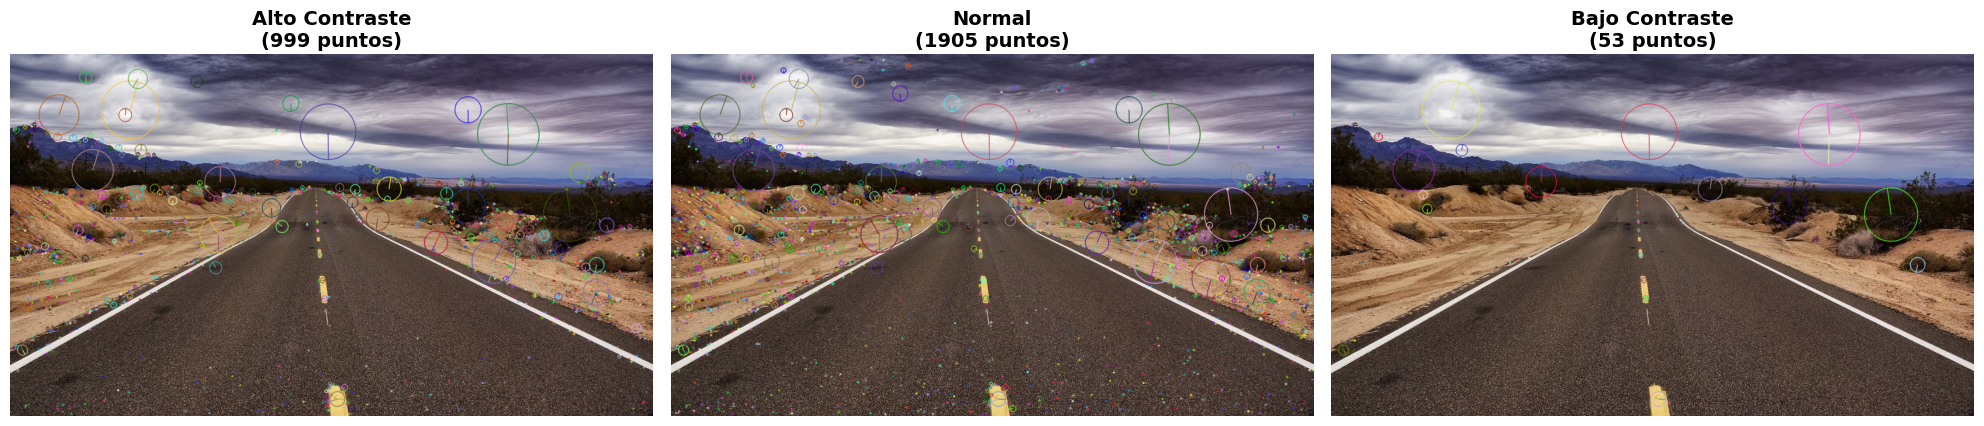

In [ ]:
mostrar_comparacion(
    [img_alto, img_con_puntos, img_bajo],
    [f"Alto Contraste\n({len(kp_alto)} puntos)",
     f"Normal\n({len(kp)} puntos)",
     f"Bajo Contraste\n({len(kp_bajo)} puntos)"]
)

In [ ]:
from google.colab import files
import io

print("Por favor, sube la imagen del objeto (e.g., box.png):")
uploaded_objeto = files.upload()

for fn_obj in uploaded_objeto.keys():
    img_data_objeto = uploaded_objeto[fn_obj]
    img_objeto = cv2.imdecode(np.frombuffer(img_data_objeto, np.uint8), cv2.IMREAD_GRAYSCALE) # Cargar como escala de grises
    print(f'Imagen de objeto "{fn_obj}" cargada con éxito. Shape: {img_objeto.shape}')
    break # Asumiendo que solo se sube un archivo por diálogo

print("\nPor favor, sube la imagen de la escena (e.g., box_in_scene.png):")
uploaded_escena = files.upload()

for fn_esc in uploaded_escena.keys():
    img_data_escena = uploaded_escena[fn_esc]
    img_escena = cv2.imdecode(np.frombuffer(img_data_escena, np.uint8), cv2.IMREAD_GRAYSCALE) # Cargar como escala de grises
    print(f'Imagen de escena "{fn_esc}" cargada con éxito. Shape: {img_escena.shape}')
    break # Asumiendo que solo se sube un archivo por diálogo

Por favor, sube la imagen del objeto (e.g., box.png):


Saving batman2.png to batman2.png
Imagen de objeto "batman2.png" cargada con éxito. Shape: (215, 128)

Por favor, sube la imagen de la escena (e.g., box_in_scene.png):


Saving estanteria.jpg to estanteria (1).jpg
Imagen de escena "estanteria (1).jpg" cargada con éxito. Shape: (2070, 3641)


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
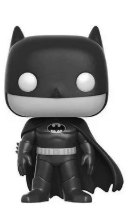

In [ ]:

img_objeto

In [ ]:
img_escena

array([[118, 113, 113, ..., 146, 146, 147],
       [113, 111, 113, ..., 146, 146, 147],
       [110, 110, 112, ..., 146, 147, 147],
       ...,
       [102, 100,  99, ..., 122, 119, 120],
       [101, 100,  98, ..., 125, 123, 121],
       [101,  99,  97, ..., 126, 123, 122]], dtype=uint8)

In [ ]:
# Inicializamos un detector SIFT para la tarea de coincidencia de objetos.
# Aquí, utilizamos la configuración predeterminada de SIFT.
# Para optimizar el rendimiento en la coincidencia, podrías ajustar los mismos parámetros de SIFT (contrastThreshold, edgeThreshold, etc.)
# para encontrar un equilibrio entre el número y la calidad de los puntos clave detectados en ambas imágenes.
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img_objeto, None) # Puntos clave y descriptores para la imagen del objeto
kp2, des2 = sift.detectAndCompute(img_escena, None) # Puntos clave y descriptores para la imagen de la escena

In [ ]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)

In [ ]:
buenos_matches = []
ratio_threshold = .9

for match in matches:
    # Verificar que haya al menos 2 candidatos
    if len(match) == 2:
        m, n = match  # m=mejor, n=segundo mejor

        # Ratio Test
        if m.distance < ratio_threshold * n.distance:
            buenos_matches.append([m])

In [ ]:
buenos_matches

[[< cv2.DMatch 0x7ab86103fd70>],
 [< cv2.DMatch 0x7ab86103e8b0>],
 [< cv2.DMatch 0x7ab86103e790>],
 [< cv2.DMatch 0x7ab86103e930>],
 [< cv2.DMatch 0x7ab86103e530>],
 [< cv2.DMatch 0x7ab86103e630>],
 [< cv2.DMatch 0x7ab86103e890>],
 [< cv2.DMatch 0x7ab86103da30>],
 [< cv2.DMatch 0x7ab861078e30>],
 [< cv2.DMatch 0x7ab86107bab0>],
 [< cv2.DMatch 0x7ab861041db0>],
 [< cv2.DMatch 0x7ab861042e70>],
 [< cv2.DMatch 0x7ab861040190>],
 [< cv2.DMatch 0x7ab8610404f0>],
 [< cv2.DMatch 0x7ab861040610>],
 [< cv2.DMatch 0x7ab8610435b0>],
 [< cv2.DMatch 0x7ab8610435f0>],
 [< cv2.DMatch 0x7ab861043730>],
 [< cv2.DMatch 0x7ab861043770>],
 [< cv2.DMatch 0x7ab861043830>],
 [< cv2.DMatch 0x7ab861043870>],
 [< cv2.DMatch 0x7ab8610438f0>],
 [< cv2.DMatch 0x7ab8610439b0>]]

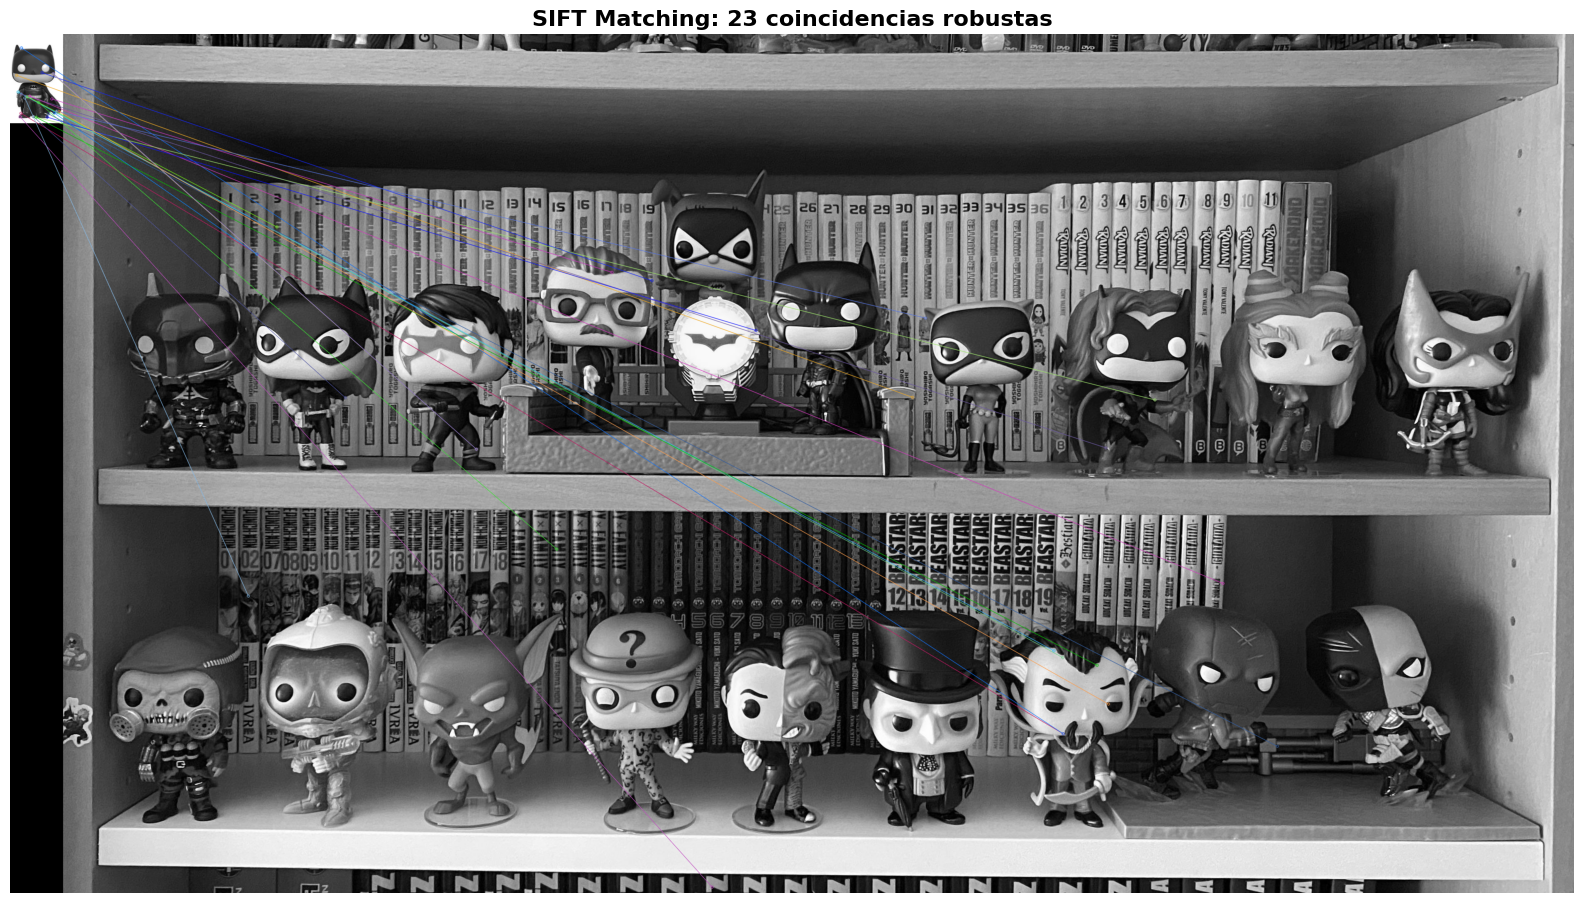

In [ ]:


# Luego, realizamos el dibujo de las coincidencias entre los puntos clave de ambas imágenes.
# cv2.drawMatchesKnn crea una nueva imagen combinando img_objeto y img_escena lado a lado,
# y luego dibuja las líneas de coincidencia entre ellas. Por diseño, no hay superposición de las imágenes originales.
img_matches = cv2.drawMatchesKnn(
    img_objeto, kp1,
    img_escena, kp2,
    buenos_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Finalmente, mostramos la imagen resultante con las coincidencias dibujadas.
mostrar(img_matches,
        f"SIFT Matching: {len(buenos_matches)} coincidencias robustas",
        figsize=(16, 10))